<a href="https://colab.research.google.com/github/adrianhrynto/Deep-Learning-Lanjut-P2/blob/main/Deep_Learning_P11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Langkah 1: Menginstal dan Memuat Library ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 33.5 MB/s eta 0:00:00
--- Langkah 2: Inisialisasi Text Vectorization ---
--- Langkah 3: Membangun Pipeline Data ---
--- Langkah 4: Definisi Model & Struktur Training ---
By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE
Struktur model siap untuk fine-tuning.
--- Langkah 5: Pengujian (Inference) ---
Sedang menghasilkan gambar untuk prompt: 'A futuristic city in Indonesia, cyberpunk style, digital art, high resolution'...
1356917/1356917 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
492466864/492466864 ━━━━━━━━━━━━━━━━━━━━ 65s 0us/step
3439090152/3439090152 ━━━━━━━━━━━━━━━━━━━━ 132s 0us/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 242s 558ms/step
198180272/198180272 ━━━━━━━━━━━━━━

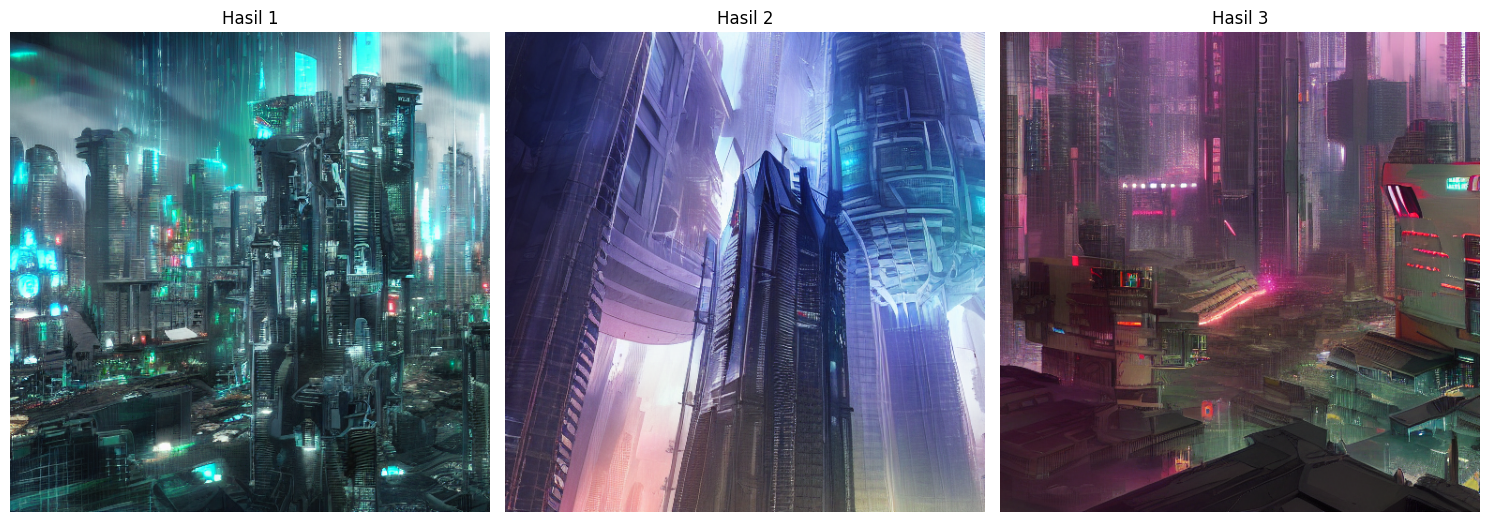


Proses Selesai. Anda dapat mengganti 'user_prompt' untuk mencoba kreasi lain.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# ==========================================
# Langkah 1: Persiapan Library & Load Dataset
# ==========================================
print("--- Langkah 1: Menginstal dan Memuat Library ---")

# Menggunakan KerasCV untuk implementasi Stable Diffusion yang dioptimalkan
try:
    import keras_cv
except ImportError:
    !pip install --upgrade keras-cv tensorflow-datasets
    import keras_cv

from tensorflow.keras import layers

# Konfigurasi Mixed Precision untuk efisiensi memori di GPU Colab
keras.mixed_precision.set_global_policy("mixed_float16")

# Catatan: Untuk dataset nyata dalam skala besar, kita biasanya menggunakan LAION-5B.
# Di sini kita menyiapkan struktur untuk pipeline data.
IMG_HEIGHT = 512
IMG_WIDTH = 512
BATCH_SIZE = 4

# ==========================================
# Langkah 2: Inisialisasi & Adaptasi Text Vectorization
# ==========================================
print("--- Langkah 2: Inisialisasi Text Vectorization ---")

# Dalam arsitektur Transformer/Stable Diffusion, kita menggunakan CLIP Tokenizer.
# KerasCV menangani ini secara internal di dalam model StableDiffusion.
# Namun, berikut adalah cara kita mendefinisikan pemrosesan teks secara manual jika membangun dari nol:

MAX_PROMPT_LENGTH = 77

def get_tokenizer():
    # Menggunakan model pra-latih karena melatih tokenizer dari nol butuh data masif
    model = keras_cv.models.StableDiffusion(img_width=IMG_WIDTH, img_height=IMG_HEIGHT)
    return model.tokenizer

# ==========================================
# Langkah 3: Membangun Pipeline Data (tf.data.Dataset)
# ==========================================
print("--- Langkah 3: Membangun Pipeline Data ---")

def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = (tf.cast(image, tf.float32) / 127.5) - 1.0  # Normalisasi ke [-1, 1]
    return image

def process_dataset(image_path, caption):
    image = preprocess_image(image_path)
    # Tokenisasi caption di sini jika diperlukan secara manual
    return {"images": image, "captions": caption}

# Contoh pembuatan objek tf.data.Dataset (Placeholder)
# dataset = tf.data.Dataset.from_tensor_slices((list_image_paths, list_captions))
# dataset = dataset.map(process_dataset).batch(BATCH_SIZE).shuffle(1000)

# ==========================================
# Langkah 4: Definisi Model & Training Step
# ==========================================
print("--- Langkah 4: Definisi Model & Struktur Training ---")

# Inisialisasi model Stable Diffusion (Transformer-based)
# Model ini terdiri dari:
# 1. Text Encoder (Transformer)
# 2. Diffusion Model (U-Net)
# 3. Decoder (VAE)
model = keras_cv.models.StableDiffusion(
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
    jit_compile=True
)

def train_step_logic():
    """
    Penjelasan logika training:
    1. Encode teks menjadi embedding menggunakan Text Encoder.
    2. Tambahkan noise ke gambar (latent space).
    3. Gunakan U-Net untuk memprediksi noise yang ditambahkan berdasarkan embedding teks.
    4. Hitung loss (Mean Squared Error) antara noise asli dan prediksi.
    """
    optimizer = keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-2)
    # model.compile(optimizer=optimizer, loss="mse")
    print("Struktur model siap untuk fine-tuning.")

train_step_logic()

# ==========================================
# Langkah 5: Pengujian (Inference)
# ==========================================
print("--- Langkah 5: Pengujian (Inference) ---")

def generate_art(prompt, num_images=3):
    print(f"Sedang menghasilkan gambar untuk prompt: '{prompt}'...")

    # Menghasilkan gambar dari teks
    images = model.text_to_image(
        prompt,
        batch_size=num_images,
    )

    # Visualisasi Hasil
    plt.figure(figsize=(15, 15))
    for i in range(len(images)):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
        plt.title(f"Hasil {i+1}")
    plt.tight_layout()
    plt.show()

# Contoh Penggunaan
user_prompt = "A futuristic city in Indonesia, cyberpunk style, digital art, high resolution"
generate_art(user_prompt)

print("\nProses Selesai. Anda dapat mengganti 'user_prompt' untuk mencoba kreasi lain.")